# MLPF on Muon Collider Data

Adapted from `notebooks/clic/mlpf-pytorch-entrypoint.ipynb`. Trains the standard MLPF transformer on muon collider ttbar events.

The only difference from the CLIC version is data loading: instead of TFDS, we load directly from the parquet files produced by `mlpf/data/key4hep/postprocessing.py`.

In [1]:
import glob
import os

import numpy as np
import pyarrow.parquet as pq
import torch
import tqdm
from torch import Tensor, nn
from torch.nn.utils.rnn import pad_sequence
import torch.nn.functional as F
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
RANDOM_SEED = 42
DATA_DIR = os.path.expanduser("~/muoncollider_all")  # change to PVC path when running on NRP

N_X_FEATURES = 17  # max(16 track features, 17 cluster features)
N_Y_FEATURES = 13
labels = [0, 211, 130, 22, 11, 13]  # PDG codes -> class indices


def load_parquet(path):
    """Load one parquet file and return a list of per-event dicts with keys X and ytarget."""
    row = pq.read_table(path).to_pydict()
    events = []
    n_events = len(row["X_track"][0])  # file has 1 parquet row; [0] gives the list of events
    for iev in range(n_events):
        X1 = np.array(row["X_track"][0][iev]).reshape(-1, 16)    # (N_trk, 16)
        X2 = np.array(row["X_cluster"][0][iev]).reshape(-1, 17)  # (N_cl, 17)
        yt_trk = np.array(row["ytarget_track"][0][iev]).reshape(-1, 13)
        yt_cl  = np.array(row["ytarget_cluster"][0][iev]).reshape(-1, 13)

        if X1.shape[0] == 0 and X2.shape[0] == 0:
            continue
        if X1.shape[0] == 0:
            X1 = np.zeros((0, N_X_FEATURES))
        if X2.shape[0] == 0:
            X2 = np.zeros((0, N_X_FEATURES))

        # pad track features to same width as cluster features
        if X1.shape[1] < N_X_FEATURES:
            X1 = np.pad(X1, [[0, 0], [0, N_X_FEATURES - X1.shape[1]]])

        X       = np.concatenate([X1, X2]).astype(np.float32)
        ytarget = np.concatenate([yt_trk, yt_cl]).astype(np.float32)

        if X.shape[0] != ytarget.shape[0]:
            continue

        # replace raw PDG codes with class indices
        ytarget[:, 0] = np.array([labels.index(int(p)) if int(p) in labels else 0
                                   for p in ytarget[:, 0]])

        events.append({"X": X, "ytarget": ytarget})
    return events

np.random.seed(RANDOM_SEED)
files = sorted(glob.glob(os.path.join(DATA_DIR, "*.parquet")))
print(f"Found {len(files)} parquet files")

all_events = []
for f in files:
    all_events.extend(load_parquet(f))

print(f"Total events loaded: {len(all_events)}")
print(f"First event X shape: {all_events[0]['X'].shape}")
print(f"First event ytarget shape: {all_events[0]['ytarget'].shape}")

Found 19 parquet files
Total events loaded: 1061
First event X shape: (473, 17)
First event ytarget shape: (473, 13)


## Datasets

Load directly from parquet files — no TFDS setup needed.

In [3]:
DATA_DIR = os.path.expanduser("~/muoncollider_all")  # change to PVC path when running on NRP

N_X_FEATURES = 17  # max(16 track features, 17 cluster features)
N_Y_FEATURES = 13
labels = [0, 211, 130, 22, 11, 13]  # PDG codes -> class indices


def load_parquet(path):
    """Load one parquet file and return a list of per-event dicts with keys X and ytarget."""
    row = pq.read_table(path).to_pydict()
    events = []
    n_events = len(row["X_track"][0])  # file has 1 parquet row; [0] gives the list of events
    for iev in range(n_events):
        X1 = np.array(row["X_track"][0][iev]).reshape(-1, 16)    # (N_trk, 16)
        X2 = np.array(row["X_cluster"][0][iev]).reshape(-1, 17)  # (N_cl, 17)
        yt_trk = np.array(row["ytarget_track"][0][iev]).reshape(-1, 13)
        yt_cl  = np.array(row["ytarget_cluster"][0][iev]).reshape(-1, 13)

        if X1.shape[0] == 0 and X2.shape[0] == 0:
            continue
        if X1.shape[0] == 0:
            X1 = np.zeros((0, N_X_FEATURES))
        if X2.shape[0] == 0:
            X2 = np.zeros((0, N_X_FEATURES))

        # pad track features to same width as cluster features
        if X1.shape[1] < N_X_FEATURES:
            X1 = np.pad(X1, [[0, 0], [0, N_X_FEATURES - X1.shape[1]]])

        X       = np.concatenate([X1, X2]).astype(np.float32)
        ytarget = np.concatenate([yt_trk, yt_cl]).astype(np.float32)

        if X.shape[0] != ytarget.shape[0]:
            continue

        # replace raw PDG codes with class indices
        ytarget[:, 0] = np.array([labels.index(int(p)) if int(p) in labels else 0
                                   for p in ytarget[:, 0]])

        events.append({"X": X, "ytarget": ytarget})
    return events


files = sorted(glob.glob(os.path.join(DATA_DIR, "*.parquet")))
print(f"Found {len(files)} parquet files")

all_events = []
for f in files:
    all_events.extend(load_parquet(f))

print(f"Total events loaded: {len(all_events)}")
print(f"First event X shape: {all_events[0]['X'].shape}")
print(f"First event ytarget shape: {all_events[0]['ytarget'].shape}")

Found 19 parquet files
Total events loaded: 1061
First event X shape: (473, 17)
First event ytarget shape: (473, 13)


In [4]:
X_FEATURES_TRK = [
    "elemtype", "pt", "eta", "sin_phi", "cos_phi", "p",
    "chi2", "ndf", "dEdx", "dEdxError", "radiusOfInnermostHit",
    "tanLambda", "D0", "omega", "Z0", "time",
]
X_FEATURES_CL = [
    "elemtype", "et", "eta", "sin_phi", "cos_phi", "energy",
    "position.x", "position.y", "position.z", "iTheta",
    "energy_ecal", "energy_hcal", "energy_other", "num_hits",
    "sigma_x", "sigma_y", "sigma_z",
]
Y_FEATURES = ["cls_id", "charge", "pt", "eta", "sin_phi", "cos_phi", "energy"]
Y_CLASSES  = [0, 211, 130, 22, 11, 13]

INPUT_DIM  = max(len(X_FEATURES_TRK), len(X_FEATURES_CL))
NUM_CLASSES = len(Y_CLASSES)
print(f"INPUT_DIM={INPUT_DIM}, NUM_CLASSES={NUM_CLASSES}")

INPUT_DIM=17, NUM_CLASSES=6


## Model

Standard MLPF transformer — identical to the CLIC version.

In [5]:
class SelfAttentionLayer(nn.Module):
    def __init__(self, embedding_dim=128, num_heads=2, width=128,
                 dropout_mha=0.1, dropout_ff=0.1):
        super().__init__()
        self.act = nn.ReLU
        self.mha = nn.MultiheadAttention(embedding_dim, num_heads, dropout=dropout_mha, batch_first=True)
        self.norm0 = nn.LayerNorm(embedding_dim)
        self.norm1 = nn.LayerNorm(embedding_dim)
        self.seq = nn.Sequential(
            nn.Linear(embedding_dim, width), self.act(), nn.Linear(width, embedding_dim), self.act()
        )
        self.dropout = nn.Dropout(dropout_ff)

    def forward(self, x, mask):
        x = self.norm0(x + self.mha(x, x, x, need_weights=False)[0])
        x = self.norm1(x + self.seq(x))
        return self.dropout(x)


def ffn(input_dim, output_dim, width, act, dropout):
    return nn.Sequential(
        nn.Linear(input_dim, width), act(), nn.LayerNorm(width),
        nn.Dropout(dropout), nn.Linear(width, output_dim),
    )


class RegressionOutput(nn.Module):
    def __init__(self, embed_dim, width, act, dropout):
        super().__init__()
        self.nn = ffn(embed_dim, 1, width, act, dropout)

    def forward(self, elems, x, orig_value):
        return orig_value + self.nn(x)


def transform_batch(Xbatch):
    Xbatch = Xbatch.clone()
    Xbatch[..., 1] = torch.log(Xbatch[..., 1])
    Xbatch[..., 5] = torch.log(Xbatch[..., 5])
    Xbatch[torch.isnan(Xbatch)] = 0.0
    Xbatch[torch.isinf(Xbatch)] = 0.0
    return Xbatch


class MLPF(nn.Module):
    def __init__(self, input_dim=17, num_classes=6, num_convs=4,
                 dropout_ff=0.0, num_heads=16, head_dim=16):
        super().__init__()
        self.act = nn.ReLU
        embedding_dim = num_heads * head_dim
        width = embedding_dim

        self.nn0_id  = ffn(input_dim, embedding_dim, width, self.act, dropout_ff)
        self.nn0_reg = ffn(input_dim, embedding_dim, width, self.act, dropout_ff)
        self.conv_id  = nn.ModuleList([SelfAttentionLayer(embedding_dim, num_heads, width) for _ in range(num_convs)])
        self.conv_reg = nn.ModuleList([SelfAttentionLayer(embedding_dim, num_heads, width) for _ in range(num_convs)])

        decoding_dim = input_dim + embedding_dim
        self.nn_id = ffn(decoding_dim, num_classes, width, self.act, dropout_ff)

        embed_dim = decoding_dim + num_classes
        self.nn_pt      = RegressionOutput(embed_dim, width, self.act, dropout_ff)
        self.nn_eta     = RegressionOutput(embed_dim, width, self.act, dropout_ff)
        self.nn_sin_phi = RegressionOutput(embed_dim, width, self.act, dropout_ff)
        self.nn_cos_phi = RegressionOutput(embed_dim, width, self.act, dropout_ff)
        self.nn_energy  = RegressionOutput(embed_dim, width, self.act, dropout_ff)

    def forward(self, X, mask):
        Xn = transform_batch(X)

        emb_id  = self.nn0_id(Xn)
        emb_reg = self.nn0_reg(Xn)
        for conv in self.conv_id:  emb_id  = conv(emb_id,  mask)
        for conv in self.conv_reg: emb_reg = conv(emb_reg, mask)

        feat_id  = torch.cat([Xn, emb_id], dim=-1)
        preds_id = self.nn_id(feat_id)

        feat_reg = torch.cat([Xn, emb_reg, preds_id], dim=-1)
        preds_momentum = torch.cat([
            self.nn_pt(X, feat_reg, X[..., 1:2]),
            self.nn_eta(X, feat_reg, X[..., 2:3]),
            self.nn_sin_phi(X, feat_reg, X[..., 3:4]),
            self.nn_cos_phi(X, feat_reg, X[..., 4:5]),
            self.nn_energy(X, feat_reg, X[..., 5:6]),
        ], dim=-1)

        return preds_id, preds_momentum

## Loss function

In [6]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction="mean"):
        super().__init__()
        self.gamma = gamma
        self.reduction = reduction
        self.nll_loss = nn.NLLLoss(weight=alpha, reduction="none")

    def forward(self, x, y):
        if x.ndim > 2:
            c = x.shape[1]
            x = x.permute(0, *range(2, x.ndim), 1).reshape(-1, c)
            y = y.view(-1)
        log_p  = F.log_softmax(x, dim=-1)
        ce     = self.nll_loss(log_p, y)
        log_pt = torch.gather(log_p, 1, y.unsqueeze(-1)).squeeze(-1)
        loss   = ((1 - log_pt.exp()) ** self.gamma) * ce
        if self.reduction == "mean":
            return loss.mean()
        elif self.reduction == "sum":
            return loss.sum()
        return loss  # "none" — return per-element tensor for reshape in mlpf_loss


def mlpf_loss(y, ypred, mask):
    loss_obj_id = FocalLoss(gamma=2.0, reduction="none")
    msk = torch.unsqueeze((y["cls_id"] != 0).float(), -1)
    npart = torch.sum(y["cls_id"] != 0).clamp(min=1)

    ypred["momentum"] = ypred["momentum"] * msk
    y["momentum"]     = y["momentum"] * msk

    loss_cls = loss_obj_id(ypred["cls_id_onehot"].permute(0, 2, 1), y["cls_id"]).reshape(y["cls_id"].shape)
    loss_reg = F.huber_loss(ypred["momentum"], y["momentum"], reduction="none")

    mom_norm = y["momentum"][y["cls_id"] != 0].std(axis=0).clamp(min=1e-6)

    loss = {}
    loss["Classification"] = loss_cls.sum() / npart
    loss["Regression"]     = (loss_reg[y["cls_id"] != 0] / mom_norm).sum() / npart
    loss["Total"]          = loss["Classification"] + loss["Regression"]
    return loss


def unpack_target(y):
    ret = {"cls_id": y[..., 0].long()}
    for i, feat in enumerate(Y_FEATURES[2:], 2):
        ret[feat] = y[..., i].float()
    ret["phi"]      = torch.atan2(ret["sin_phi"], ret["cos_phi"])
    ret["momentum"] = y[..., 2:7].float()
    return ret


def unpack_predictions(preds):
    ret = {"cls_id_onehot": preds[0], "momentum": preds[1]}
    ret["pt"]      = ret["momentum"][..., 0]
    ret["eta"]     = ret["momentum"][..., 1]
    ret["sin_phi"] = ret["momentum"][..., 2]
    ret["cos_phi"] = ret["momentum"][..., 3]
    ret["energy"]  = ret["momentum"][..., 4]
    ret["cls_id"]  = torch.argmax(ret["cls_id_onehot"], dim=-1)
    ret["phi"]     = torch.atan2(ret["sin_phi"], ret["cos_phi"])
    return ret





## Training

In [9]:
n_train          = int(0.8 * len(all_events))
train_events     = all_events[:n_train]
val_events       = all_events[n_train:]
events_per_batch = 4   # increase if you have more RAM/GPU memory
nepochs          = 100

print(f"Training on {len(train_events)} events, validating on {len(val_events)} events")

device = "cpu"
model     = MLPF(input_dim=INPUT_DIM, num_classes=NUM_CLASSES).to(device)
optimizer = torch.optim.Adam(lr=1e-4, params=model.parameters())

loss_train_epochs, loss_val_epochs = [], []

for epoch in range(nepochs):
    model.train()
    step_losses = []
    for i in tqdm.trange(0, len(train_events), events_per_batch, desc=f"Epoch {epoch}"):
        batch = train_events[i : i + events_per_batch]

        X_list = [torch.tensor(e["X"]) for e in batch]
        y_list = [torch.tensor(e["ytarget"]) for e in batch]
        X_pad  = pad_sequence(X_list, batch_first=True).to(device)
        y_pad  = pad_sequence(y_list, batch_first=True).to(device)
        mask   = X_pad[:, :, 0] != 0

        optimizer.zero_grad()
        preds   = model(X_pad, mask)
        loss    = mlpf_loss(unpack_target(y_pad), unpack_predictions(preds), mask)
        loss["Total"].backward()
        optimizer.step()
        step_losses.append(loss["Total"].item())

    # validation
    model.eval()
    val_losses = []
    with torch.no_grad():
        for i in range(0, len(val_events), events_per_batch):
            batch  = val_events[i : i + events_per_batch]
            X_list = [torch.tensor(e["X"]) for e in batch]
            y_list = [torch.tensor(e["ytarget"]) for e in batch]
            X_pad  = pad_sequence(X_list, batch_first=True).to(device)
            y_pad  = pad_sequence(y_list, batch_first=True).to(device)
            mask   = X_pad[:, :, 0] != 0
            preds  = model(X_pad, mask)
            loss   = mlpf_loss(unpack_target(y_pad), unpack_predictions(preds), mask)
            val_losses.append(loss["Total"].item())

    loss_train_epochs.append(np.mean(step_losses))
    loss_val_epochs.append(np.mean(val_losses))
    print(f"Epoch {epoch}: train={loss_train_epochs[-1]:.3f}  val={loss_val_epochs[-1]:.3f}")

Training on 848 events, validating on 213 events


Epoch 0: 100%|██████████| 212/212 [02:15<00:00,  1.56it/s]


Epoch 0: train=2.674  val=2.025


Epoch 1: 100%|██████████| 212/212 [02:14<00:00,  1.58it/s]


Epoch 1: train=2.102  val=1.845


...

Epoch 97: train=1.210  val=1.348


Epoch 98: 100%|██████████| 212/212 [04:33<00:00,  1.29s/it]


Epoch 98: train=1.208  val=1.339


Epoch 99: 100%|██████████| 212/212 [04:31<00:00,  1.28s/it]


Epoch 99: train=1.205  val=1.347


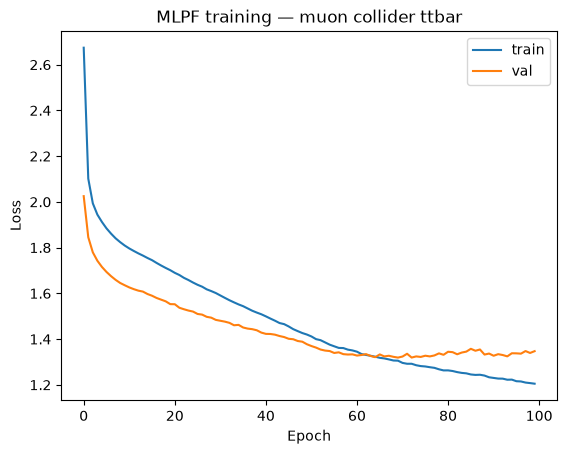

In [10]:
plt.plot(loss_train_epochs, label="train")
plt.plot(loss_val_epochs,   label="val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("MLPF training — muon collider ttbar")
plt.show()

## Evaluation

Run inference on the validation set and plot predicted vs true quantities.

In [11]:
model.eval()
model.to("cpu")

X_list = [torch.tensor(e["X"]) for e in val_events]
y_list = [torch.tensor(e["ytarget"]) for e in val_events]
X_pad  = pad_sequence(X_list, batch_first=True)
y_pad  = pad_sequence(y_list, batch_first=True)
mask   = X_pad[:, :, 0] != 0

with torch.no_grad():
    preds = model(X_pad, mask)

preds_unpacked  = unpack_predictions((preds[0].detach(), preds[1].detach()))
targets_unpacked = unpack_target(y_pad)

msk_true = targets_unpacked["cls_id"] != 0

pt_target     = targets_unpacked["pt"][msk_true].numpy()
pt_pred       = preds_unpacked["pt"][msk_true].numpy()
eta_target    = targets_unpacked["eta"][msk_true].numpy()
eta_pred      = preds_unpacked["eta"][msk_true].numpy()
energy_target = targets_unpacked["energy"][msk_true].numpy()
energy_pred   = preds_unpacked["energy"][msk_true].numpy()

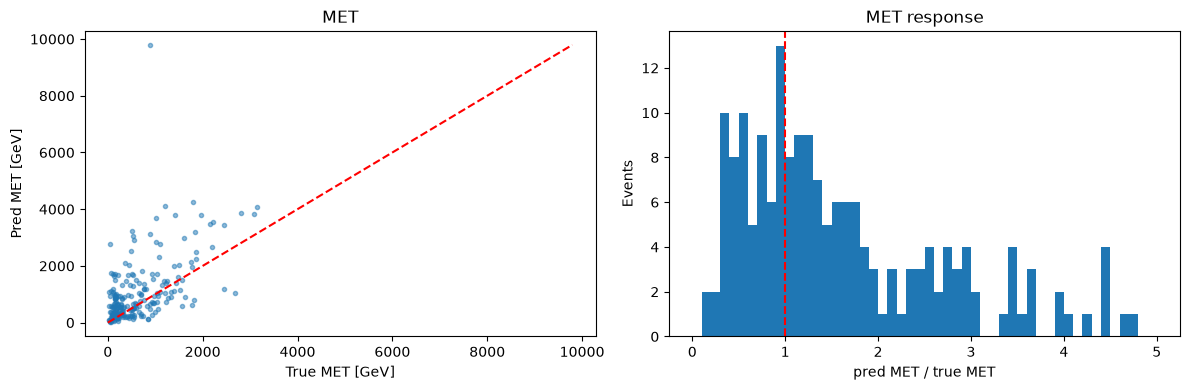

In [12]:
# MET: vector sum of pT over all predicted true particles
msk_f = msk_true.float().unsqueeze(-1)
px_pred = (preds_unpacked["pt"]  * preds_unpacked["cos_phi"]  * msk_true).sum(dim=-1)
py_pred = (preds_unpacked["pt"]  * preds_unpacked["sin_phi"]  * msk_true).sum(dim=-1)
px_true = (targets_unpacked["pt"] * targets_unpacked["cos_phi"] * msk_true).sum(dim=-1)
py_true = (targets_unpacked["pt"] * targets_unpacked["sin_phi"] * msk_true).sum(dim=-1)
pred_met = torch.sqrt(px_pred**2 + py_pred**2)
true_met = torch.sqrt(px_true**2 + py_true**2)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(true_met.numpy(), pred_met.numpy(), marker=".", alpha=0.5)
axes[0].set(xlabel="True MET [GeV]", ylabel="Pred MET [GeV]", title="MET")
lim = max(true_met.max().item(), pred_met.max().item())
axes[0].plot([0, lim], [0, lim], "r--")
axes[1].hist((pred_met / true_met.clamp(min=0.1)).numpy(), bins=50, range=(0, 5))
axes[1].axvline(1.0, color="red", linestyle="--")
axes[1].set(xlabel="pred MET / true MET", ylabel="Events", title="MET response")
plt.tight_layout()
plt.show()

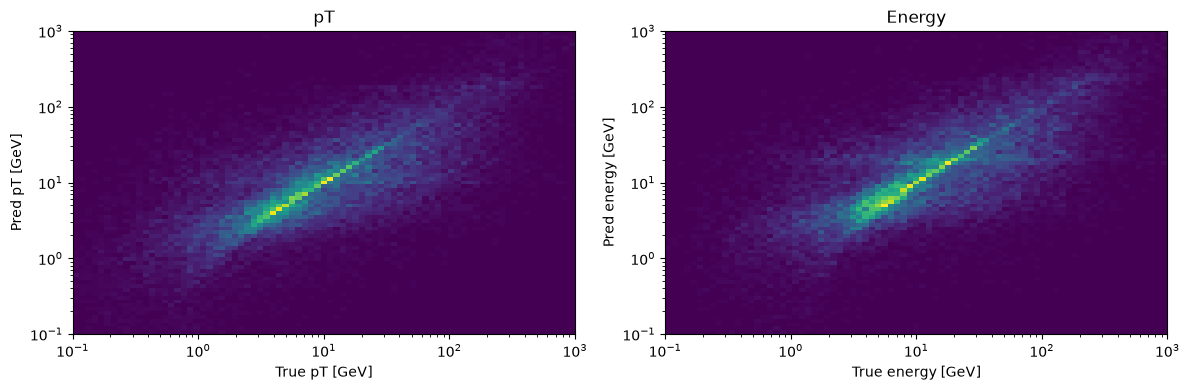

In [13]:
b = np.logspace(-1, 3, 80)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist2d(pt_target, pt_pred, bins=(b, b))
axes[0].set_xscale("log"); axes[0].set_yscale("log")
axes[0].set(xlabel="True pT [GeV]", ylabel="Pred pT [GeV]", title="pT")
axes[1].hist2d(energy_target, energy_pred, bins=(b, b))
axes[1].set_xscale("log"); axes[1].set_yscale("log")
axes[1].set(xlabel="True energy [GeV]", ylabel="Pred energy [GeV]", title="Energy")
plt.tight_layout()
plt.show()

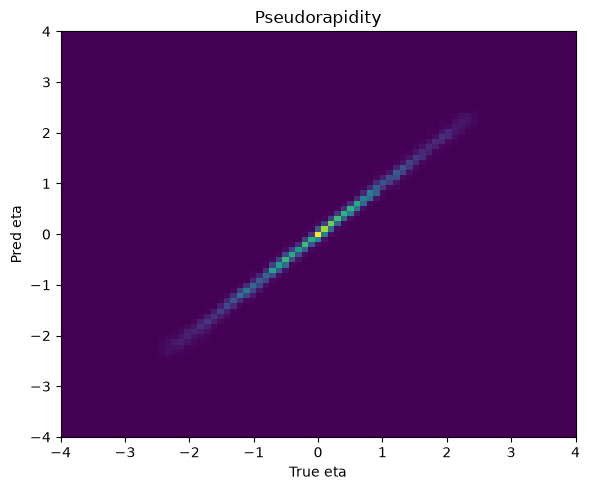

In [14]:
b = np.linspace(-4, 4, 80)
fig, ax = plt.subplots(figsize=(6, 5))
ax.hist2d(eta_target, eta_pred, bins=(b, b))
ax.set(xlabel="True eta", ylabel="Pred eta", title="Pseudorapidity")
plt.tight_layout()
plt.show()

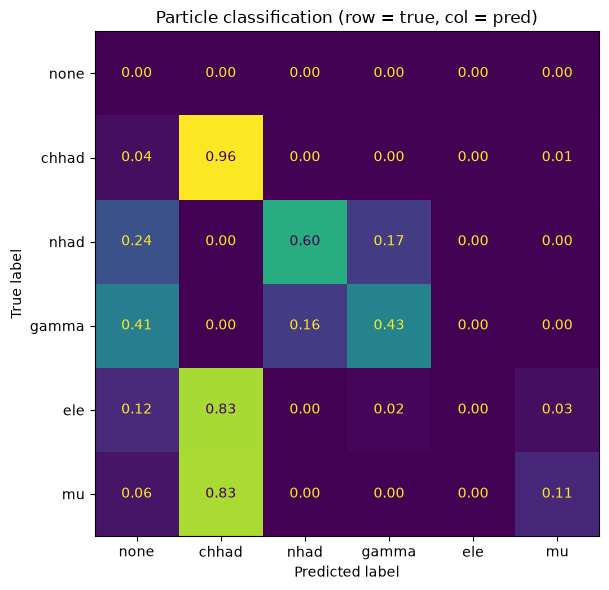

In [15]:
# Particle type confusion matrix
cls_true = targets_unpacked["cls_id"][msk_true].numpy()
cls_pred = preds_unpacked["cls_id"][msk_true].numpy()
class_names = ["none", "chhad", "nhad", "gamma", "ele", "mu"]

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(cls_true, cls_pred, labels=list(range(NUM_CLASSES)), normalize="true")
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
disp.plot(ax=ax, colorbar=False, values_format=".2f")
ax.set_title("Particle classification (row = true, col = pred)")
plt.tight_layout()
plt.show()